# **Project 1: Working with CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.

# 1. Data Processing (CNN)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Load the raw CIFAR-10 dataset

In [6]:
print("Downloading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

Dataset information:

In [7]:
print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Pixel value range: [{x_train.min()}, {x_train.max()}]")

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Pixel value range: [0, 255]


CIFAR-10 classes

In [8]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
          'dog', 'frog', 'horse', 'ship', 'truck']
print(f"Dataset classes: {classes}")

Dataset classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


VISUALIZE SAMPLE IMAGES:

Displaying 10 random images from the dataset...


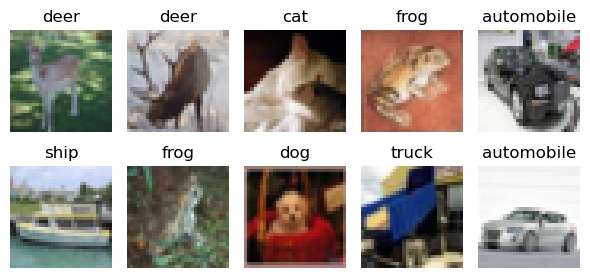

In [9]:
print("Displaying 10 random images from the dataset...")

# Initialize a grid of subplots with 2 rows and 5 columns
fig, axes = plt.subplots(2, 5, figsize=(6,3))

# Flatten the 2D axes array into a 1D array for easier iteration [1, 2, ..., 10]
axes = axes.ravel()


# Iterate to display 10 random samples
for i in range(10):
    # Select a random index from the training set
    idx = np.random.randint(0, len(x_train))
    
    # Render the image at the selected index
    axes[i].imshow(x_train[idx])
    
    # Set the title using the human-readable class name from the 'classes' list
    # Note: y_train[idx][0] accesses the label integer for the selected image
    axes[i].set_title(f"{classes[y_train[idx][0]]}")
    
    # Hide the x and y axes for a cleaner visual presentation
    axes[i].axis('off')

# Adjust the layout to prevent titles from overlapping
plt.tight_layout()

# Export the figure as a PNG file for documentation/GitHub README
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')

# Display the final plot
plt.show()

# Normalization (Feature Scaling) (CNN)

In [10]:
# Convert pixel values from [0, 255] to [0, 1] for numerical stability
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0
print(f"Pixel value range: [{x_train_normalized.min()}, {x_train_normalized.max()}]")

Pixel value range: [0.0, 1.0]


# Preparing Labels: One-Hot Encoding (CNN)

In [11]:
# Convert class vectors (integers) to binary class matrices
# Necessary for the Categorical Crossentropy loss function

num_classes = 10
y_train_encoded = to_categorical(y_train, num_classes)
y_test_encoded = to_categorical(y_test, num_classes)

print(f"Shape of y_train after one-hot encoding: {y_train_encoded.shape}")
print(f"Shape of y_test after one-hot encoding: {y_test_encoded.shape}")


Shape of y_train after one-hot encoding: (50000, 10)
Shape of y_test after one-hot encoding: (10000, 10)


# 2. Model Architecture:  (CNN)
 - Design a CNN architecture suitable for image classification.

In [12]:
# Designing a CNN architecture

print("Creating CNN model...")

def create_cnn_model():
    """
    Constructs a Convolutional Neural Network (CNN) using the Keras Sequential API.
    
    The architecture follows a common pattern: Feature Extraction (Conv + Pool) 
    followed by Classification (Flatten + Dense).
    """
    model = models.Sequential([
        # --- First Convolutional Block ---
        # 32 filters of size 3x3 to extract low-level features (edges, textures).
        # 'padding=same' ensures the output size matches the input size.
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        # Reduce spatial dimensions by half (from 32x32 to 16x16) to focus on the most important features.
        layers.MaxPooling2D((2, 2)),
        # Regularization: Randomly turn off 25% of neurons to prevent 'Overfitting'.
        layers.Dropout(0.25),
        
        # --- Second Convolutional Block ---
        # Increase filter count to 64 to capture more complex patterns (shapes, object parts).
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        # Further downsample the feature maps (from 16x16 to 8x8).
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # # --- Third Convolutional Block ---
        # # Increase filter count to 128 to capture more complex patterns (shapes, object parts).
        # layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        # layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        # # Further downsample the feature maps (from 16x16 to 8x8).
        # layers.MaxPooling2D((2, 2)),
        # layers.Dropout(0.25),
        
        # --- Classification Head (Fully Connected Layers) ---
        # Flatten the 3D feature maps into a 1D vector to feed into the Dense layers.
        layers.Flatten(),
        # A large hidden layer with 512 neurons to learn the relationships between features.
        layers.Dense(512, activation='relu'),
        # Higher dropout (50%) to ensure the model generalizes well to unseen data.
        layers.Dropout(0.5),
        # Final output layer: 10 neurons (one per CIFAR-10 class) with 'Softmax' 
        # to output a probability distribution.
        layers.Dense(10, activation='softmax')
    ])
    
    return model

# Instantiate the model
model_cnn = create_cnn_model()
# Print the model architecture, parameter count, and output shapes.
model_cnn.summary()

Creating CNN model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,362 (8.27 MB)

 Trainable params: 2,168,362 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

# 3. Compile Model (CNN)

In [13]:
# --- Model Compilation ---
# We define the three essential components for training:
model_cnn.compile(
    # 1. Loss Function: Measures how "wrong" the model's predictions are. 
    # Categorical Crossentropy is the standard for multi-class classification (like CIFAR-10).
    loss='categorical_crossentropy', 
    
    # 2. Optimizer: The algorithm that updates the weights to minimize the loss.
    # 'Adam' it adapts the learning rate automatically.
    optimizer='adam', 
    
    # 3. Metrics: What we want to monitor during training to judge performance.
    metrics=['accuracy']
)

Data Augmentation

In [14]:
print("Configuring data augmentation...")

# Initialize the ImageDataGenerator which will apply random transformations
# to the images in real-time during the training process.
datagen = ImageDataGenerator(
    # Randomly rotate images by up to 15 degrees
    rotation_range=15,
    
    # Randomly shift images horizontally by 10% of the total width
    width_shift_range=0.1,
    
    # Randomly shift images vertically by 10% of the total height
    height_shift_range=0.1,
    
    # Randomly flip images horizontally (ideal for objects like cars or animals)
    horizontal_flip=True,
    
    # Randomly zoom inside pictures by up to 20%
    zoom_range=0.2
)

Configuring data augmentation...


Early Stopping

In [15]:
print("Model CNN - EarlyStopping...")

# Define the EarlyStopping callback to monitor the training process
early_stop = EarlyStopping(
    # Monitor: The metric to watch. We track 'val_loss' to see when the model 
    # stops generalizing to new data.
    monitor='val_loss',
    
    # Patience: The number of epochs to wait after the last improvement. 
    # If val_loss doesn't improve for 10 epochs, training will be terminated.
    patience=10,
    
    # Restore Best Weights: Crucial for performance. Once training stops, the model 
    # will revert to the weights from the epoch with the lowest validation loss, 
    # rather than staying with the final, potentially overfitted weights.
    restore_best_weights=True
)

Model CNN - EarlyStopping...


# 4. Training Model

In [16]:
# --- Training Configuration ---
# Batch Size: The number of images the model looks at before updating its internal weights.

BATCH_SIZE = 128

# Epochs: The maximum number of times the model will go through the entire dataset.
# We set it to 100, but 'EarlyStopping' will likely stop it much sooner to save time.
EPOCHS = 100

# --- The Training Loop ---
# We store the results in 'history_cnn' to plot the learning curves later.
history_cnn = model_cnn.fit(
    # Use the 'datagen' to feed augmented images to the model in real-time
    datagen.flow(x_train_normalized, y_train_encoded, batch_size=BATCH_SIZE),
    
    epochs=EPOCHS,  
    
    # Provide the test set to evaluate how well the model generalizes after each epoch
    validation_data=(x_test_normalized, y_test_encoded),
    
    # Attach our EarlyStopping logic here
    callbacks=[early_stop],
    
    # Verbose=1 shows a progress bar and metrics for each epoch in the console
    verbose=1
)

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 111ms/step - accuracy: 0.3739 - loss: 1.7000 - val_accuracy: 0.5303 - val_loss: 1.2921
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 112ms/step - accuracy: 0.4957 - loss: 1.3993 - val_accuracy: 0.5729 - val_loss: 1.1860
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.5560 - loss: 1.2457 - val_accuracy: 0.6003 - val_loss: 1.1181
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 115ms/step - accuracy: 0.5931 - loss: 1.1440 - val_accuracy: 0.6710 - val_loss: 0.9366
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.6216 - loss: 1.0628 - val_accuracy: 0.6806 - val_loss: 0.9191
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 121ms/step - accuracy: 0.6436 - loss: 1.0122 - val_accuracy: 0.7038 - val_loss: 0.8598
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 119ms/step - accuracy: 0.6620 - loss: 0.9638 - val_accuracy: 0.7038 - val_loss: 0.8828
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - accuracy: 0.6744 -

Visualize Training

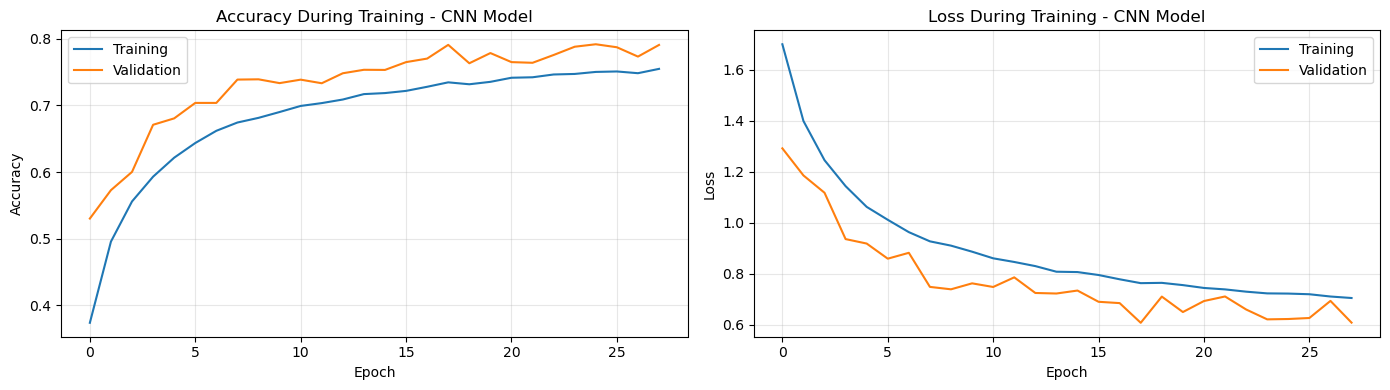

In [17]:
# Create a figure with 1 row and 2 columns of subplots for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Left Plot: Training vs. Validation Accuracy ---
# Plot the accuracy of the training data and the unseen validation data per epoch
axes[0].plot(history_cnn.history['accuracy'], label='Training')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validation')
axes[0].set_xlabel('Epoch') # The horizontal axis represents passes through the dataset
axes[0].set_ylabel('Accuracy') # The vertical axis represents the percentage of correct predictions
axes[0].set_title('Accuracy During Training - CNN Model')
axes[0].legend() # Show the labels to distinguish between Training and Validation
axes[0].grid(True, alpha=0.3) # Add a subtle grid for better readability

# --- Right Plot: Training vs. Validation Loss ---
# Plot the loss (error) value for both sets. We want these values to decrease.
axes[1].plot(history_cnn.history['loss'], label='Training')
axes[1].plot(history_cnn.history['val_loss'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss') # Represents the 'cost' or error of the model
axes[1].set_title('Loss During Training - CNN Model')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Finalize and export the visualization
plt.tight_layout() # Adjust spacing to prevent overlapping
plt.savefig('training_metrics_cnn.png', dpi=100, bbox_inches='tight') # Save for documentation
plt.show()

# 4. Model Evaluation (CNN)

In [18]:
print("Evaluating CNN Model...")

# Use the 'evaluate' method to get the final loss and accuracy on the unseen test set.
# 'verbose=0' keeps the output clean by hiding the progress bar.
test_loss_cnn, test_accuracy_cnn = model_cnn.evaluate(x_test_normalized, y_test_encoded, verbose=1)

# Display the final performance metrics. We multiply by 100 for a readable percentage.
print(f"\nAccuracy on test set: {test_accuracy_cnn * 100:.2f}%")
print(f"Loss on test set: {test_loss_cnn:.4f}")

# --- Inference and Predictions ---
# 'predict' returns the raw probabilities for each class (10 values per image).
y_pred_cnn = model_cnn.predict(x_test_normalized)

# Use 'argmax' to find the index of the highest probability (the predicted class).
# 'axis=1' means we look horizontally across the 10 class scores for each image.
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)

# Convert the true labels (one-hot encoded) back to single integers for comparison.
y_test_classes = np.argmax(y_test_encoded, axis=1)

Evaluating CNN Model...
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7909 - loss: 0.6086

Accuracy on test set: 79.09%
Loss on test set: 0.6086
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


Detailed Metrics: Precision, Recall & F1-score

In [ ]:
# --- EVALUATION PHASE: Analyzing the Model's Performance ---

# 1. Print a detailed breakdown of metrics for each of the 10 categories
# y_test_classes: The ground truth (actual labels)
# y_pred_classes_cnn: What our model predicted
print("\n=== METRICS BY CLASS ===\n")
print(classification_report(y_test_classes, y_pred_classes_cnn, target_names=classes))

# 2. Calculate Global Metrics using 'weighted' average
# 'weighted' accounts for class imbalance by calculating the mean based on the number of samples per class
precision_cnn = precision_score(y_test_classes, y_pred_classes_cnn, average='weighted')
recall_cnn = recall_score(y_test_classes, y_pred_classes_cnn, average='weighted')
f1_cnn = f1_score(y_test_classes, y_pred_classes_cnn, average='weighted')

# 3. Display the final scores formatted to 4 decimal places
print(f"\n=== GLOBAL METRICS ===")
print(f"Precision: {precision_cnn:.4f}")
print(f"Recall: {recall_cnn:.4f}")
print(f"F1-Score: {f1_cnn:.4f}")


=== METRICS BY CLASS ===

              precision    recall  f1-score   support

    airplane       0.82      0.86      0.84      1000
  automobile       0.93      0.91      0.92      1000
        bird       0.85      0.62      0.72      1000
         cat       0.74      0.56      0.64      1000
        deer       0.79      0.78      0.79      1000
         dog       0.78      0.73      0.75      1000
        frog       0.70      0.94      0.80      1000
       horse       0.80      0.90      0.85      1000
        ship       0.91      0.90      0.91      1000
       truck       0.84      0.93      0.89      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000


=== GLOBAL METRICS ===
Precision: 0.8161
Recall: 0.8131
F1-Score: 0.8091


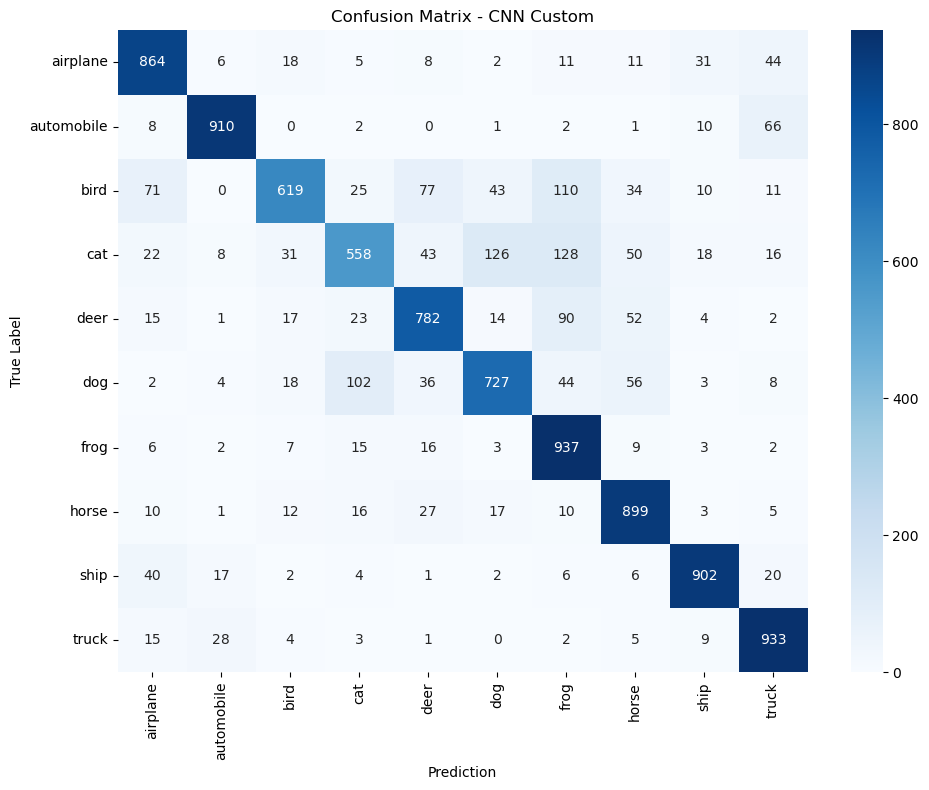

In [ ]:
# --- EVALUATION: Visualizing Model Performance with a Confusion Matrix ---

# 1. Compute the confusion matrix by comparing actual labels with model predictions
cm_cnn = confusion_matrix(y_test_classes, y_pred_classes_cnn)

# 2. Set up the figure size for the plot
plt.figure(figsize=(10, 8))

# 3. Create a heatmap to visualize the matrix
# annot=True: displays the actual number of samples in each cell
# fmt='d': formats the numbers as integers (decimals)
# cmap='Blues': uses a blue color scale (darker means higher count)
# xticklabels/yticklabels: labels the axes with the class names (airplane, dog, etc.)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)

# 4. Add axis labels and a descriptive title
plt.xlabel('Prediction') # Label for the horizontal axis
plt.ylabel('True Label') # Label for the vertical axis
plt.title('Confusion Matrix - CNN Custom')

# 5. Optimize the layout to ensure labels don't overlap
plt.tight_layout()

# 6. Save the plot as a high-quality PNG file for the technical report
plt.savefig('confusion_matrix_cnn.png', dpi=100, bbox_inches='tight')

# 7. Display the plot in the notebook
plt.show()

# 5. Transfer Learning
- Evaluate the accuracy of your model on a pre-trained models like ImagNet, VGG16, Inception... (pick one an justify your choice)
- Perform transfer learning with your chosen pre-trained models i.e., you will probably try a few and choose the best one.

In [ ]:
print("\n\n=== TRANSFER LEARNING WITH MULTIPLE MODELS ===\n")

# Define an EarlyStopping callback to prevent overfitting and save computation time
# - monitor='val_loss': Watch the validation error
# - patience=5: Stop training if the error doesn't improve for 5 consecutive epochs
# - restore_best_weights=True: Ensure the model keeps the parameters from its peak performance
early_stop_tl = EarlyStopping(monitor='val_loss', 
                              patience=5, 
                              restore_best_weights=True)



=== TRANSFER LEARNING WITH MULTIPLE MODELS ===



# Transfer Learning with VGG16


In [ ]:
# --- MODEL INITIALIZATION: Loading the pre-trained backbone ---

# Instantiate the VGG16 architecture from Keras Applications
base_model_vgg = keras.applications.VGG16(
    # Define the input dimensions to match CIFAR-10 images (32x32 pixels, RGB)
    input_shape=(32, 32, 3),
    
    # Exclude the fully-connected output layers (the 'top') 
    # This allows us to append our own custom classifier for the 10 classes
    include_top=False,
    
    # Load weights pre-trained on the ImageNet dataset 
    # This enables Transfer Learning by leveraging existing visual knowledge
    weights='imagenet'
)

In [ ]:
# --- FREEZING PHASE: Preserving pre-trained knowledge ---

# Freeze the weights of the VGG16 base model
# This prevents the pre-trained ImageNet weights from being updated
# during the initial training of our custom classification head.
base_model_vgg.trainable = False

In [ ]:
# --- ARCHITECTURE ASSEMBLY: Building the custom Classification Head ---

# We use the Sequential API to stack layers linearly
model_vgg = models.Sequential([
    # 1. Include the pre-trained VGG16 backbone (the 'frozen' feature extractor)
    base_model_vgg,
    
    # 2. Convert the 2D feature maps from the backbone into a 1D vector
    layers.Flatten(),
    
    # 3. Fully connected layer with 256 neurons to learn complex patterns
    # 'relu' (Rectified Linear Unit) is the standard activation for hidden layers
    layers.Dense(256, activation='relu'),
    
    # 4. Regularization layer: Randomly drops 50% of neurons during training
    # This is critical to prevent overfitting and improve generalization
    layers.Dropout(0.5),
    
    # 5. Output layer: 10 neurons (one for each CIFAR-10 class)
    # 'softmax' converts the raw output into a probability distribution (0 to 1)
    layers.Dense(10, activation='softmax')
])

In [ ]:
# --- COMPILATION: Configuring the learning strategy ---

model_vgg.compile(
    # 1. Optimizer: The algorithm that updates the model's weights to reduce error.
    # Adam is an adaptive optimizer that adjusts the learning rate for each parameter.
    # learning_rate=0.001: Defines the step size for the gradient descent process.
    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    # 2. Loss Function: Measures how far the model's predictions are from the truth.
    # 'categorical_crossentropy' is the standard loss for multi-class classification 
    # when labels are one-hot encoded.
    loss='categorical_crossentropy',

    # 3. Metrics: Human-readable performance tracking during training and evaluation.
    # 'accuracy' calculates the percentage of correctly predicted images.
    metrics=['accuracy']
)

In [ ]:
# --- MODEL TRAINING: Executing the Learning Process ---

print("Training VGG16...")

# Start the training process using the .fit() method
# We use the normalized features and one-hot encoded labels
history_vgg = model_vgg.fit(
    x_train_normalized, y_train_encoded,
    
    # Run the full training set 25 times
    epochs=25, 
    
    # Process 128 images at a time before updating the gradients (Batch Gradient Descent)
    batch_size=128,
    
    # Evaluate the model on unseen data (test set) at the end of each epoch
    validation_data=(x_test_normalized, y_test_encoded),
    
    # Implement EarlyStopping to stop training if validation loss doesn't improve for 5 epochs
    # 'restore_best_weights=True' keeps the model version with the lowest loss
    callbacks=[early_stop_tl],
    
    # Show a progress bar and metrics for each epoch in the console
    verbose=1
)

Training VGG16...
Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 114s 291ms/step - accuracy: 0.1736 - loss: 2.1540 - val_accuracy: 0.1885 - val_loss: 2.1054
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 123s 316ms/step - accuracy: 0.1798 - loss: 2.1146 - val_accuracy: 0.1907 - val_loss: 2.1006
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 113s 289ms/step - accuracy: 0.1808 - loss: 2.1105 - val_accuracy: 0.1880 - val_loss: 2.0986
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 113s 289ms/step - accuracy: 0.1831 - loss: 2.1083 - val_accuracy: 0.1898 - val_loss: 2.0984
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 121s 309ms/step - accuracy: 0.1828 - loss: 2.1077 - val_accuracy: 0.1916 - val_loss: 2.0974
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 117s 300ms/step - accuracy: 0.1838 - loss: 2.1065 - val_accuracy: 0.1935 - val_loss: 2.0967
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 120s 308ms/step - accuracy: 0.1843 - loss: 2.1052 - val_accuracy: 0.1893 - val_loss: 2.0970
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 122s 313ms/step - 

In [ ]:
# Complete model evaluation: loss/accuracy, classification report, and metrics  VGG16

# True predictions and labels
y_true = np.argmax(y_test, axis=1)
probs = model_vgg.predict(x_test)
y_pred = np.argmax(probs, axis=1)


print("Evaluating VGG16 Model...")

# Use the 'evaluate' method to get the final loss and accuracy on the unseen test set.
# 'verbose=0' keeps the output clean by hiding the progress bar.
test_loss_VGG, test_accuracy_vgg = model_vgg.evaluate(x_test_normalized, y_test_encoded, verbose=1)

# Display the final performance metrics. We multiply by 100 for a readable percentage.
print(f"\nAccuracy on test set: {test_accuracy_vgg * 100:.2f}%")
print(f"Loss on test set: {test_loss_cnn:.4f}")

# --- Inference and Predictions ---
# 'predict' returns the raw probabilities for each class (10 values per image).
y_pred_vgg = model_vgg.predict(x_test_normalized)

# Use 'argmax' to find the index of the highest probability (the predicted class).
# 'axis=1' means we look horizontally across the 10 class scores for each image.
y_pred_classes_vgg = np.argmax(y_pred_vgg, axis=1)

# Convert the true labels (one-hot encoded) back to single integers for comparison.
y_test_classes = np.argmax(y_test_encoded, axis=1)

 VGG16 Accuracy: 62.06%

313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step
Evaluating VGG16 Model...
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.6206 - loss: 1.0846

Accuracy on test set: 62.06%
Loss on test set: 0.5449
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 80ms/step


In [ ]:
# --- EVALUATION: Generating Final Performance Metrics for VGG16 ---

# 1. Print the detailed Classification Report
# This provides Precision, Recall, and F1-score for each of the 10 CIFAR-10 classes
print("\n=== METRICS BY CLASS ===\n")
print(classification_report(y_test_classes, y_pred_classes_vgg, target_names=classes))

# 2. Compute Global Metrics using the 'weighted' average
# 'weighted' calculates the mean of metrics, accounting for the number of samples in each class
precision_vgg = precision_score(y_test_classes, y_pred_classes_vgg, average='weighted')
recall_vgg = recall_score(y_test_classes, y_pred_classes_vgg, average='weighted')
f1_vgg = f1_score(y_test_classes, y_pred_classes_vgg, average='weighted')

# 3. Print the final global scores formatted to 4 decimal places for precision
print(f"\n=== GLOBAL METRICS ===")
print(f"Precision: {precision_vgg:.4f}")
print(f"Recall: {recall_vgg:.4f}")
print(f"F1-Score: {f1_vgg:.4f}")


=== METRICS BY CLASS ===



              precision    recall  f1-score   support

    airplane       0.73      0.68      0.70      1000
  automobile       0.63      0.74      0.68      1000
        bird       0.56      0.51      0.53      1000
         cat       0.46      0.40      0.43      1000
        deer       0.59      0.55      0.57      1000
         dog       0.56      0.53      0.54      1000
        frog       0.60      0.72      0.66      1000
       horse       0.68      0.68      0.68      1000
        ship       0.72      0.75      0.74      1000
       truck       0.64      0.64      0.64      1000

    accuracy                           0.62     10000
   macro avg       0.62      0.62      0.62     10000
weighted avg       0.62      0.62      0.62     10000


=== GLOBAL METRICS ===
Precision: 0.6181
Recall: 0.6206
F1-Score: 0.6178


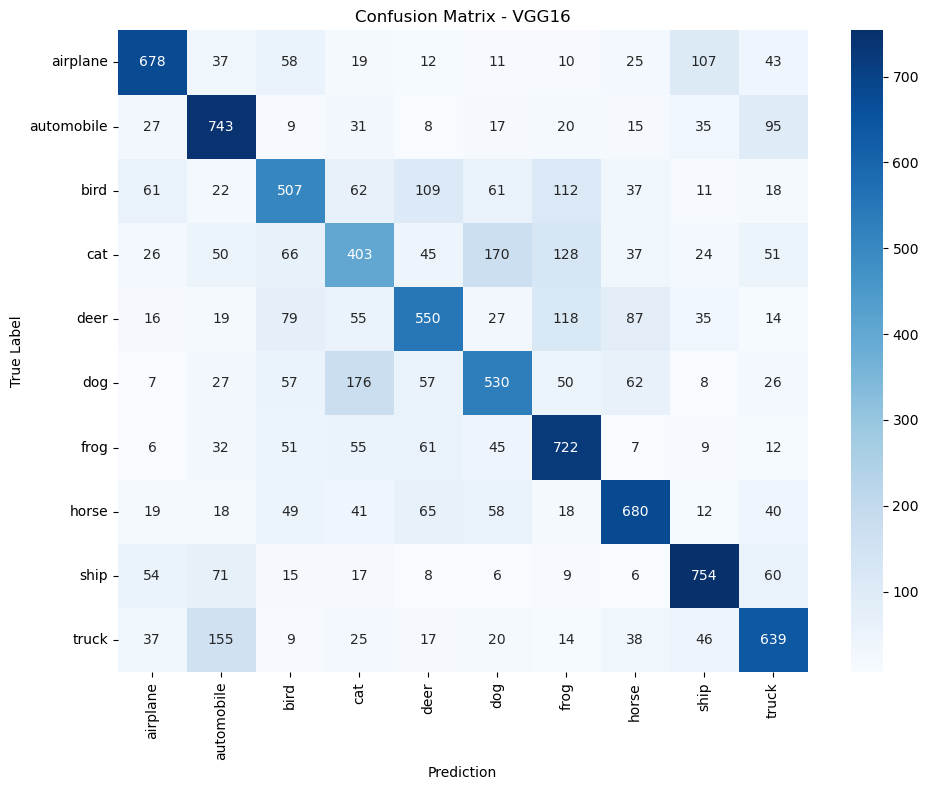

In [ ]:
# --- VISUALIZATION: Analyzing Error Patterns with a Confusion Matrix ---

# 1. Compute the confusion matrix for the VGG16 model
# This cross-references the actual ground truth (y_test_classes) 
# with the model's predictions (y_pred_classes_vgg)
cm_vgg = confusion_matrix(y_test_classes, y_pred_classes_vgg)

# 2. Initialize the plotting area with specific dimensions
plt.figure(figsize=(10, 8))

# 3. Generate a heatmap to represent the matrix visually
# annot=True: displays the sample count in each cell
# fmt='d': forces integer formatting for the counts
# cmap='Blues': applies a color gradient where darker blue indicates higher values
# xticklabels/yticklabels: maps the index numbers to class names (e.g., 'airplane')
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)

# 4. Define axis titles and the main plot title
plt.xlabel('Prediction') # X-axis represents what the model predicted
plt.ylabel('True Label')  # Y-axis represents what the image actually was
plt.title('Confusion Matrix - VGG16')

# 5. Automatically adjust subplot parameters for a clean layout
plt.tight_layout()

# 6. Export the visualization as a PNG file for the project documentation
plt.savefig('confusion_matrix_vgg.png', dpi=100, bbox_inches='tight')

# 7. Render the final plot in the notebook
plt.show()


# Transfer Learning with MobileNetV2


In [8]:
# --- MODEL INITIALIZATION: Loading the Lightweight MobileNetV2 Backbone ---

print("TRAINING MobileNetV2...\n")

# Instantiate the MobileNetV2 architecture from Keras Applications
base_model_mobilenet = keras.applications.MobileNetV2(
    # Set the input resolution to match CIFAR-10's 32x32 RGB images
    input_shape=(32, 32, 3),
    
    # Exclude the default 1,000-class classification head (ImageNet)
    # This enables us to use the model as a pre-trained feature extractor
    include_top=False,
    
    # Initialize the model with weights optimized on the ImageNet dataset
    # This is the core of Transfer Learning for this mobile-optimized architecture
    weights='imagenet'
)

TRAINING MobileNetV2...



In [9]:
# Freeze base model weights
base_model_mobilenet.trainable = False

In [10]:
# --- ARCHITECTURE ASSEMBLY: Building the MobileNetV2 Classification Head ---

# Initialize a Sequential model to stack our layers in a linear order
model_mobilenet = models.Sequential([
    # 1. Add the pre-trained MobileNetV2 base (the frozen feature extractor)
    base_model_mobilenet,
    
    # 2. Flatten the 2D feature maps from the backbone into a 1D vector
    # This prepares the data for the fully connected (Dense) layers
    layers.Flatten(),
    
    # 3. Hidden Dense layer with 256 neurons to interpret extracted features
    # 'relu' activation helps the model learn non-linear relationships
    layers.Dense(256, activation='relu'),
    
    # 4. Dropout layer with a 0.5 rate to mitigate overfitting
    # It randomly deactivates 50% of neurons during training to force robustness
    layers.Dropout(0.5),
    
    # 5. Output layer with 10 neurons (one for each CIFAR-10 category)
    # 'softmax' provides a probability distribution summing to 1.0
    layers.Dense(10, activation='softmax')
])

In [16]:
# --- COMPILATION: Defining the Optimization and Loss Strategy ---

model_mobilenet.compile(
    # 1. Optimizer: The algorithm that minimizes the error by updating weights.
    # Adam (Adaptive Moment Estimation) is ideal for MobileNetV2 due to its 
    # memory efficiency and ability to handle sparse gradients.
    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    # 2. Loss Function: The objective function the model aims to minimize.
    # 'categorical_crossentropy' is used for multi-class tasks where 
    # labels are provided in a one-hot encoded format.
    loss='categorical_crossentropy',

    # 3. Metrics: Performance indicators monitored during training.
    # 'accuracy' provides the percentage of images correctly classified.
    metrics=['accuracy']
)

In [ ]:
# --- MODEL TRAINING: Launching the Learning Process for MobileNetV2 ---

print("Training MobileNetV2...")

# Execute the training loop using the .fit() method
# We store the training logs in 'history_mobilenet' for later visualization
history_mobilenet = model_mobilenet.fit(
    # Training features (images) and labels (one-hot encoded)
    x_train_normalized, y_train_encoded,
    
    # Run the dataset for a maximum of 50 epochs (cycles)
    epochs=50,
    
    # Process 128 images before updating internal weights (Batch size)
    batch_size=128,
    
    # Evaluate performance on unseen data after each epoch to monitor generalization
    validation_data=(x_test_normalized, y_test_encoded),
    
    # Implementation of EarlyStopping to prevent overfitting:
    # - monitor='val_loss': Watch the error on the validation set
    # - patience=5: Stop if the error doesn't improve for 5 consecutive epochs
    # - restore_best_weights=True: Keep the model state with the lowest error
    callbacks=[early_stop_tl],
    
    # Show a progress bar and metrics (Accuracy/Loss) for each epoch
    verbose=1
)

Training MobileNetV2...
Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.2732 - loss: 2.0029 - val_accuracy: 0.3164 - val_loss: 1.8941
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.3139 - loss: 1.8896 - val_accuracy: 0.3299 - val_loss: 1.8591
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.3245 - loss: 1.8574 - val_accuracy: 0.3345 - val_loss: 1.8414
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.3334 - loss: 1.8376 - val_accuracy: 0.3427 - val_loss: 1.8255
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.3406 - loss: 1.8205 - val_accuracy: 0.3474 - val_loss: 1.8156
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.3470 - loss: 1.8080 - val_accuracy: 0.3514 - val_loss: 1.8096
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.3482 - loss: 1.7972 - val_accuracy: 0.3538 - val_loss: 1.8034
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 

In [17]:
# Complete model evaluation: loss/accuracy, classification report, and metrics  MobileNetV3

# True predictions and labels
y_true = np.argmax(y_test, axis=1)
probs = model_mobilenet.predict(x_test)
y_pred = np.argmax(probs, axis=1)


print("Evaluating MobileNetV3...")

# Use the 'evaluate' method to get the final loss and accuracy on the unseen test set.
# 'verbose=0' keeps the output clean by hiding the progress bar.
test_loss_mobilenet, test_accuracy_mobilenet = model_mobilenet.evaluate(x_test_normalized, y_test_encoded, verbose=1)

# Display the final performance metrics. We multiply by 100 for a readable percentage.
print(f"\nAccuracy on test set: {test_accuracy_mobilenet * 100:.2f}%")
print(f"Loss on test set: {test_loss_mobilenet:.4f}")

# --- Inference and Predictions ---
# 'predict' returns the raw probabilities for each class (10 values per image).
y_pred_mobilenet = model_mobilenet.predict(x_test_normalized)

# Use 'argmax' to find the index of the highest probability (the predicted class).
# 'axis=1' means we look horizontally across the 10 class scores for each image.
y_pred_classes_mobilenet = np.argmax(y_pred_mobilenet, axis=1)

# Convert the true labels (one-hot encoded) back to single integers for comparison.
y_test_classes = np.argmax(y_test_encoded, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Evaluating MobileNetV3...
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0856 - loss: 2.3090

Accuracy on test set: 8.56%
Loss on test set: 2.3090
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [ ]:
# --- EVALUATION: Generating Performance Metrics for MobileNetV2 ---

# 1. Print a detailed breakdown of metrics for each of the 10 categories
# This allows us to see if the model is 'biased' towards specific classes
print("\n=== METRICS BY CLASS ===\n")
print(classification_report(y_test_classes, y_pred_classes_mobilenet, target_names=classes))

# 2. Calculate Global Metrics using 'weighted' average
# This accounts for the actual distribution of samples in the test set
precision_mobilenet = precision_score(y_test_classes, y_pred_classes_mobilenet, average='weighted')
recall_mobilenet = recall_score(y_test_classes, y_pred_classes_mobilenet, average='weighted')
f1_mobilenet = f1_score(y_test_classes, y_pred_classes_mobilenet, average='weighted')

# 3. Output the final aggregated scores formatted to 4 decimal places
print(f"\n=== GLOBAL METRICS ===")
print(f"Precision: {precision_mobilenet:.4f}")
print(f"Recall: {recall_mobilenet:.4f}")
print(f"F1-Score: {f1_mobilenet:.4f}")


=== METRICS BY CLASS ===

              precision    recall  f1-score   support

    airplane       0.36      0.49      0.41      1000
  automobile       0.39      0.31      0.34      1000
        bird       0.29      0.16      0.21      1000
         cat       0.35      0.23      0.28      1000
        deer       0.39      0.40      0.39      1000
         dog       0.30      0.27      0.28      1000
        frog       0.41      0.49      0.45      1000
       horse       0.43      0.30      0.35      1000
        ship       0.35      0.37      0.36      1000
       truck       0.32      0.55      0.41      1000

    accuracy                           0.36     10000
   macro avg       0.36      0.36      0.35     10000
weighted avg       0.36      0.36      0.35     10000


=== GLOBAL METRICS ===
Precision: 0.3585
Recall: 0.3581
F1-Score: 0.3492


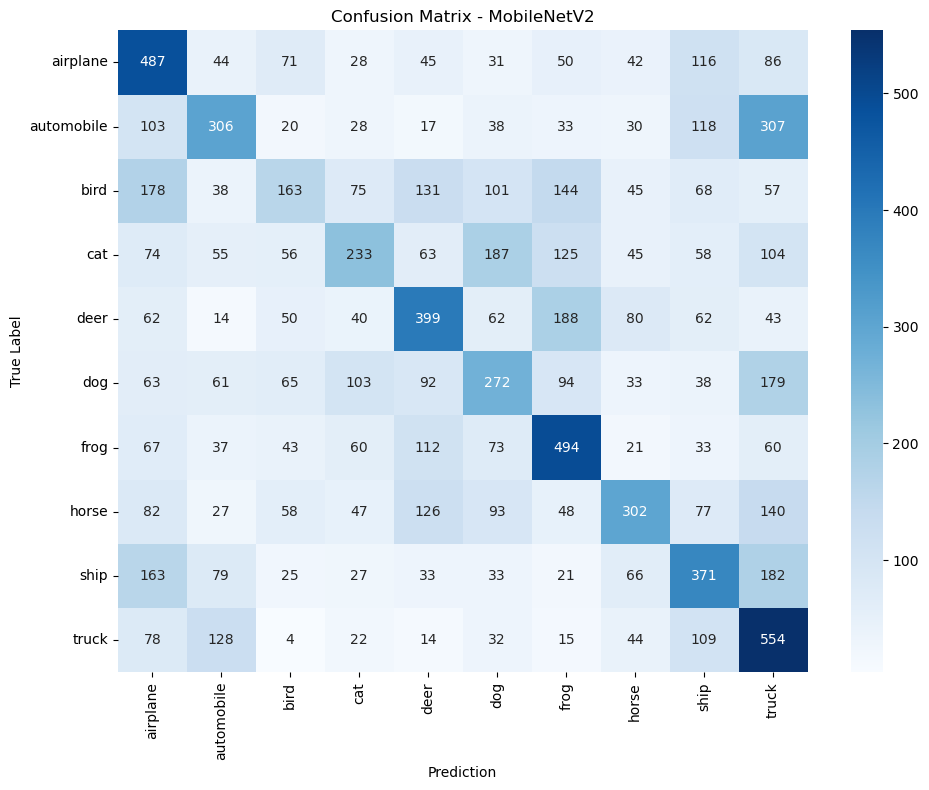

In [ ]:
# --- EVALUATION: Visualizing Error Patterns for MobileNetV2 ---

# 1. Compute the confusion matrix using ground truth and predictions
# It maps actual classes vs. predicted classes to identify specific errors
cm_mobilenet = confusion_matrix(y_test_classes, y_pred_classes_mobilenet)

# 2. Define the canvas size for the visualization
plt.figure(figsize=(10, 8))

# 3. Create a heatmap to visualize the classification results
# annot=True: displays the numeric count in each cell
# fmt='d': ensures values are rendered as integers
# cmap='Blues': uses a blue color gradient (higher intensity for higher counts)
# xticklabels/yticklabels: labels the axes with human-readable class names
sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)

# 4. Set axis labels and title for the plot
plt.xlabel('Prediction')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MobileNetV2')

# 5. Optimize the layout to prevent clipping of labels
plt.tight_layout()

# 6. Export the final plot as a high-resolution PNG for documentation
plt.savefig('confusion_matrix_mobilenet.png', dpi=100, bbox_inches='tight')

# 7. Render the plot in the current notebook session
plt.show()


# Transfer Learning with InceptionV3


In [ ]:
# --- ADVANCED TRANSFER LEARNING: Initializing the InceptionV3 Backbone ---

# Load the InceptionV3 architecture, known for its multi-scale processing
base_model_inception = keras.applications.InceptionV3(
    # NOTE: InceptionV3 requires a minimum input size of 75x75.
    # Images must be resized before being fed into this model.
    input_shape=(75, 75, 3),
    
    # Exclude the final 1,000-class dense layers to allow for a custom head
    include_top=False,
    
    # Load pre-trained weights from ImageNet to leverage high-level feature detection
    weights='imagenet'
)

In [35]:
# Freeze base model weights
base_model_inception.trainable = False

In [ ]:
# --- ADVANCED ARCHITECTURE: InceptionV3 with Dynamic Resizing ---

model_inception = models.Sequential([
    # 1. Define the input layer with native CIFAR-10 dimensions
    layers.Input(shape=(32, 32, 3)),
    
    # 2. Dynamic Resizing Layer: Scales 32x32 images up to 75x75 on the fly.
    # This fulfills InceptionV3's requirements without duplicating the 
    # dataset in RAM, preventing Out-of-Memory (OOM) errors.
    layers.Resizing(75, 75),
    
    # 3. Pre-trained InceptionV3 backbone (frozen feature extractor)
    base_model_inception,
    
    # 4. Global Average Pooling: Reduces each feature map to a single value.
    # This significantly reduces parameter count compared to Flatten(), 
    # helping to mitigate Overfitting.
    layers.GlobalAveragePooling2D(),
    
    # 5. Custom Dense Head for classification
    layers.Dense(256, activation='relu'),
    
    # 6. Dropout for regularization (50% neurons deactivated per batch)
    layers.Dropout(0.5),
    
    # 7. Final output layer for the 10 CIFAR-10 classes
    layers.Dense(10, activation='softmax')
])

In [ ]:
# --- COMPILATION: Configuring the InceptionV3 Learning Strategy ---

model_inception.compile(
    # 1. Optimizer: Adam is highly effective for deep architectures like Inception.
    # It manages the learning rate adaptively for each of the millions of parameters.
    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    # 2. Loss Function: Measures the discrepancy between predictions and actual labels.
    # Categorical Crossentropy is the gold standard for multi-class classification 
    # with one-hot encoded targets.
    loss='categorical_crossentropy',

    # 3. Metrics: Tracking performance in a human-readable format.
    # We focus on Accuracy to see the percentage of correctly classified images.
    metrics=['accuracy']
)

In [ ]:
# --- EXECUTION: Training the InceptionV3 Model ---

print("Training InceptionV3...")

# The .fit() method starts the training process
# Note: The model handles the 32x32 to 75x75 resizing internally via its layers
history_inception = model_inception.fit(
    # Feature set and one-hot encoded labels
    x_train_normalized, y_train_encoded,
    
    # We set 20 epochs; Transfer Learning usually reaches high accuracy quickly
    epochs=20,
    
    # Reduced batch size (64) to manage memory usage due to 75x75 image upscaling
    batch_size=64, 
    
    # Test the model on unseen data after every epoch
    validation_data=(x_test_normalized, y_test_encoded),
    
    # Stop training if validation loss plateaus to save time and energy
    callbacks=[early_stop_tl],
    
    # Enable the progress bar for real-time monitoring
    verbose=1
)

Training InceptionV3...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 111s 140ms/step - accuracy: 0.5160 - loss: 1.3914 - val_accuracy: 0.6072 - val_loss: 1.1389
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 133ms/step - accuracy: 0.5990 - loss: 1.1560 - val_accuracy: 0.6171 - val_loss: 1.0974
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 110s 140ms/step - accuracy: 0.6218 - loss: 1.0803 - val_accuracy: 0.6264 - val_loss: 1.0722
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 107s 136ms/step - accuracy: 0.6398 - loss: 1.0269 - val_accuracy: 0.6355 - val_loss: 1.0606
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 107s 136ms/step - accuracy: 0.6557 - loss: 0.9751 - val_accuracy: 0.6350 - val_loss: 1.0573
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 107s 137ms/step - accuracy: 0.6676 - loss: 0.9388 - val_accuracy: 0.6391 - val_loss: 1.0537
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 107s 137ms/step - accuracy: 0.6803 - loss: 0.8959 - val_accuracy: 0.6419 - val_loss: 1.0560
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 107s 136ms/s

In [ ]:
# --- EVALUATION: Final Test Set Performance and Inference ---

# 1. Manual Prediction (Initial Check)
# np.argmax converts probability vectors into discrete class labels
y_true = np.argmax(y_test, axis=1) # Get actual labels from test set
probs = model_inception.predict(x_test) # Get model confidence scores
y_pred = np.argmax(probs, axis=1) # Pick the class with the highest probability

print("Evaluating InceptionV3...")

# 2. Automated Evaluation
# The 'evaluate' method calculates the loss and accuracy directly on the test set
test_loss_inception, test_accuracy_inception = model_inception.evaluate(
    x_test_normalized, 
    y_test_encoded, 
    verbose=1
)

# 3. Performance Summary
# Displaying results in a readable percentage format (2 decimal places)
print(f"\nAccuracy on test set: {test_accuracy_inception * 100:.2f}%")
print(f"Loss on test set: {test_loss_inception:.4f}")

# 4. Detailed Inference for Reporting
# 'predict' generates raw probabilities for each of the 10 classes per image
y_pred_inception = model_inception.predict(x_test_normalized)

# 5. Winning Class Selection
# 'axis=1' ensures we find the maximum value across the class-score horizontal axis
y_pred_classes_inception = np.argmax(y_pred_inception, axis=1)

# 6. Label Alignment
# Convert one-hot encoded ground truth back to integer labels for comparison metrics
y_test_classes = np.argmax(y_test_encoded, axis=1)

 VGG16 Accuracy: 63.91%

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step
Evaluating InceptionV2...
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.6391 - loss: 1.0537

Accuracy on test set: 63.91%
Loss on test set: 1.0537
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step


In [ ]:
# --- EVALUATION: Detailed Performance Analysis for InceptionV3 ---

# 1. Generate and print a comprehensive classification report per class.
# This displays Precision, Recall, and F1-score for each label in 'classes'.
print("\n=== METRICS BY CLASS ===\n")
print(classification_report(y_test_classes, y_pred_classes_inception, target_names=classes))

# 2. Compute the Global Weighted Metrics.
# The 'weighted' average accounts for class imbalance by weighting each class 
# by its 'support' (the number of true instances for that label).

# Precision: The ratio of correctly predicted positive observations to the total predicted positives.
precision_inception = precision_score(y_test_classes, y_pred_classes_inception, average='weighted')

# Recall (Sensitivity): The ratio of correctly predicted positive observations to all observations in the actual class.
recall_inception = recall_score(y_test_classes, y_pred_classes_inception, average='weighted')

# F1-Score: The harmonic mean of Precision and Recall. It is the best single-number metric for model quality.
f1_inception = f1_score(y_test_classes, y_pred_classes_inception, average='weighted')

# 3. Display the final aggregated results formatted to 4 decimal places.
print(f"\n=== GLOBAL METRICS ===")
print(f"Precision: {precision_inception:.4f}")
print(f"Recall: {recall_inception:.4f}")
print(f"F1-Score: {f1_inception:.4f}")


=== METRICS BY CLASS ===

              precision    recall  f1-score   support

    airplane       0.67      0.71      0.69      1000
  automobile       0.69      0.76      0.73      1000
        bird       0.54      0.55      0.55      1000
         cat       0.48      0.48      0.48      1000
        deer       0.60      0.55      0.58      1000
         dog       0.68      0.54      0.60      1000
        frog       0.60      0.70      0.65      1000
       horse       0.69      0.70      0.69      1000
        ship       0.70      0.72      0.71      1000
       truck       0.73      0.68      0.71      1000

    accuracy                           0.64     10000
   macro avg       0.64      0.64      0.64     10000
weighted avg       0.64      0.64      0.64     10000


=== GLOBAL METRICS ===
Precision: 0.6398
Recall: 0.6391
F1-Score: 0.6378


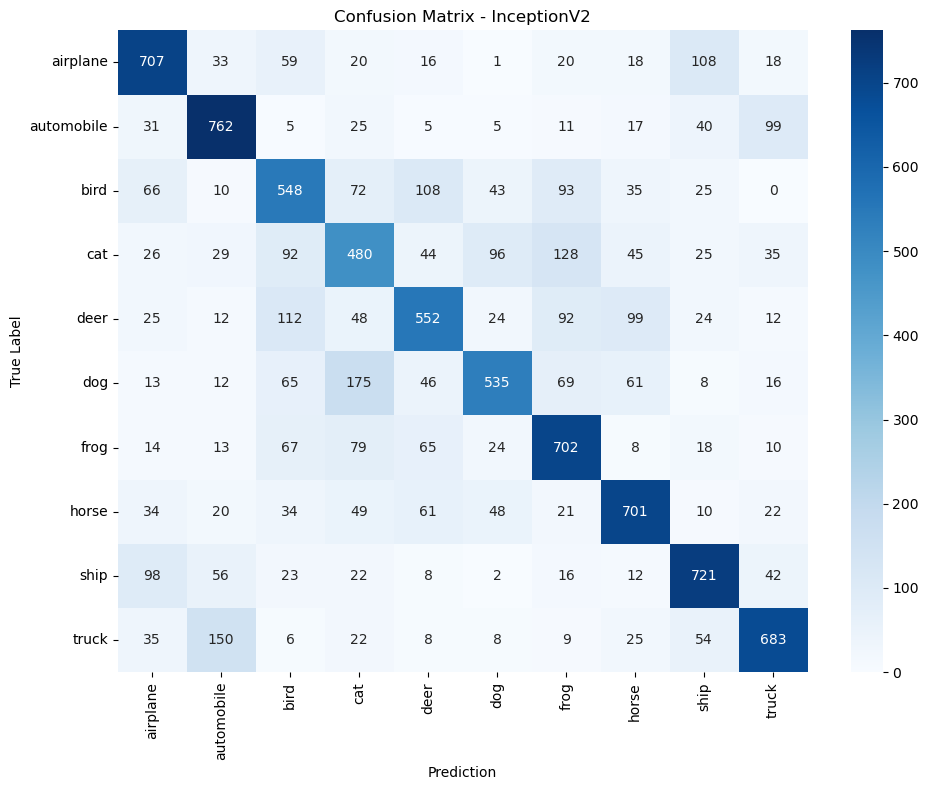

In [ ]:
# --- ERROR ANALYSIS: Visualizing Misclassifications for InceptionV3 ---

# 1. Generate the confusion matrix data
# It computes the frequency of true vs. predicted labels
cm_inception = confusion_matrix(y_test_classes, y_pred_classes_inception)

# 2. Configure the plot appearance
plt.figure(figsize=(10, 8))

# 3. Plot the heatmap using Seaborn
# annot=True: overlay the raw counts on each cell
# fmt='d': display numbers as integers
# cmap='Blues': use a blue gradient to highlight density
# xticklabels/yticklabels: map indices to class names for readability
sns.heatmap(cm_inception, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)

# 4. Define axis titles and a descriptive plot title
plt.xlabel('Prediction')
plt.ylabel('True Label')
plt.title('Confusion Matrix - InceptionV3')

# 5. Final adjustments and export
plt.tight_layout() # Ensure labels are not cut off
plt.savefig('confusion_matrix_inception.png', dpi=100, bbox_inches='tight')

# 6. Render the visualization
plt.show()


# COMPARISON OF ALL MODELS


In [ ]:
# --- BENCHMARKING: Aggregating Results for Cross-Model Analysis ---
print("=== COMPARISON OF ALL MODELS ===")


# 2. Store the accuracy results in a dictionary for easy comparison
# We multiply by 100 to present the data as percentages (%)
results = {
    # Our custom-built baseline architecture
    'CNN Custom': test_accuracy_cnn * 100,
    
    # Heavyweight Transfer Learning model (High parameters)
    'VGG16': test_accuracy_vgg * 100,
    
    # Lightweight Transfer Learning model (Mobile-optimized)
    'MobileNetV2': test_accuracy_mobilenet * 100,
    
    # Advanced Multi-scale architecture (Requires upscaling)
    'InceptionV3': test_accuracy_inception * 100
}


=== COMPARISON OF ALL MODELS ===



In [ ]:
# --- REPORTING: Displaying the Final Leaderboard ---

# Iterate through the results dictionary sorted by accuracy in descending order
# 1. results.items() returns key-value pairs.
# 2. key=lambda x: x[1] tells the sort function to look at the accuracy (the value).
# 3. reverse=True ensures the highest accuracy is shown at the top.
for model_name, accuracy in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:.<30} {accuracy:.2f}%")

CNN Custom.................... 81.31%
InceptionV3................... 63.91%
VGG16......................... 62.06%
MobileNetV2................... 35.81%


In [ ]:
# --- DECISION MAKING: Identifying the Champion Model ---

# Use the max() function with a key to find the dictionary key 
# associated with the highest accuracy value.
# results.get returns the value (accuracy) for each key (model name).
best_model_name = max(results, key=results.get)

# Retrieve the specific accuracy score for the winning model
best_accuracy = results[best_model_name]

# Output the champion model with clear formatting for the final report
print(f"BEST MODEL: {best_model_name} ({best_accuracy:.2f}%)")

 BEST MODEL: CNN Custom (81.31%)


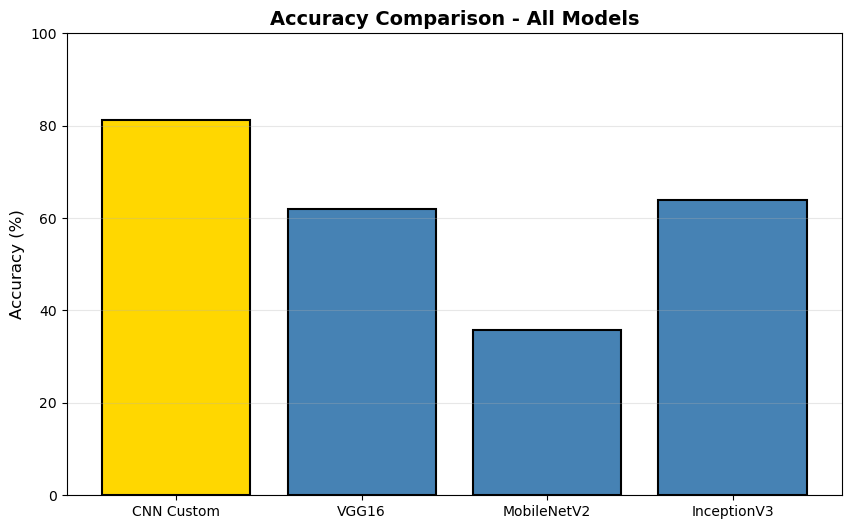

In [ ]:
# --- VISUALIZATION: Comparative Benchmarking of Model Accuracy ---

# 1. Create the figure and axis objects for the plot
# Using a 10x6 ratio ensures the chart is readable in reports and slides
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Extract data from the results dictionary
model_names = list(results.keys())
accuracies = list(results.values())

# 3. Dynamic Coloring: Assign 'gold' to the champion model and 'steelblue' to others
# This visual cue immediately directs the viewer's attention to the best result
colors = ['gold' if m == best_model_name else 'steelblue' for m in model_names]

# 4. Generate the bar chart with custom styling
bars = ax.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)

# 5. Labeling and Aesthetics
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy Comparison - All Models', fontsize=14, fontweight='bold')

# 6. Set Y-axis scale from 0 to 100% for a fair comparison of performance
ax.set_ylim([0, 100])

# 7. Add a subtle horizontal grid to assist in reading specific percentage values
ax.grid(axis='y', alpha=0.3)

# Recommendation: Save the plot for your GitHub README
plt.savefig('model_comparison_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()


# COMPARE TRAINING CURVES


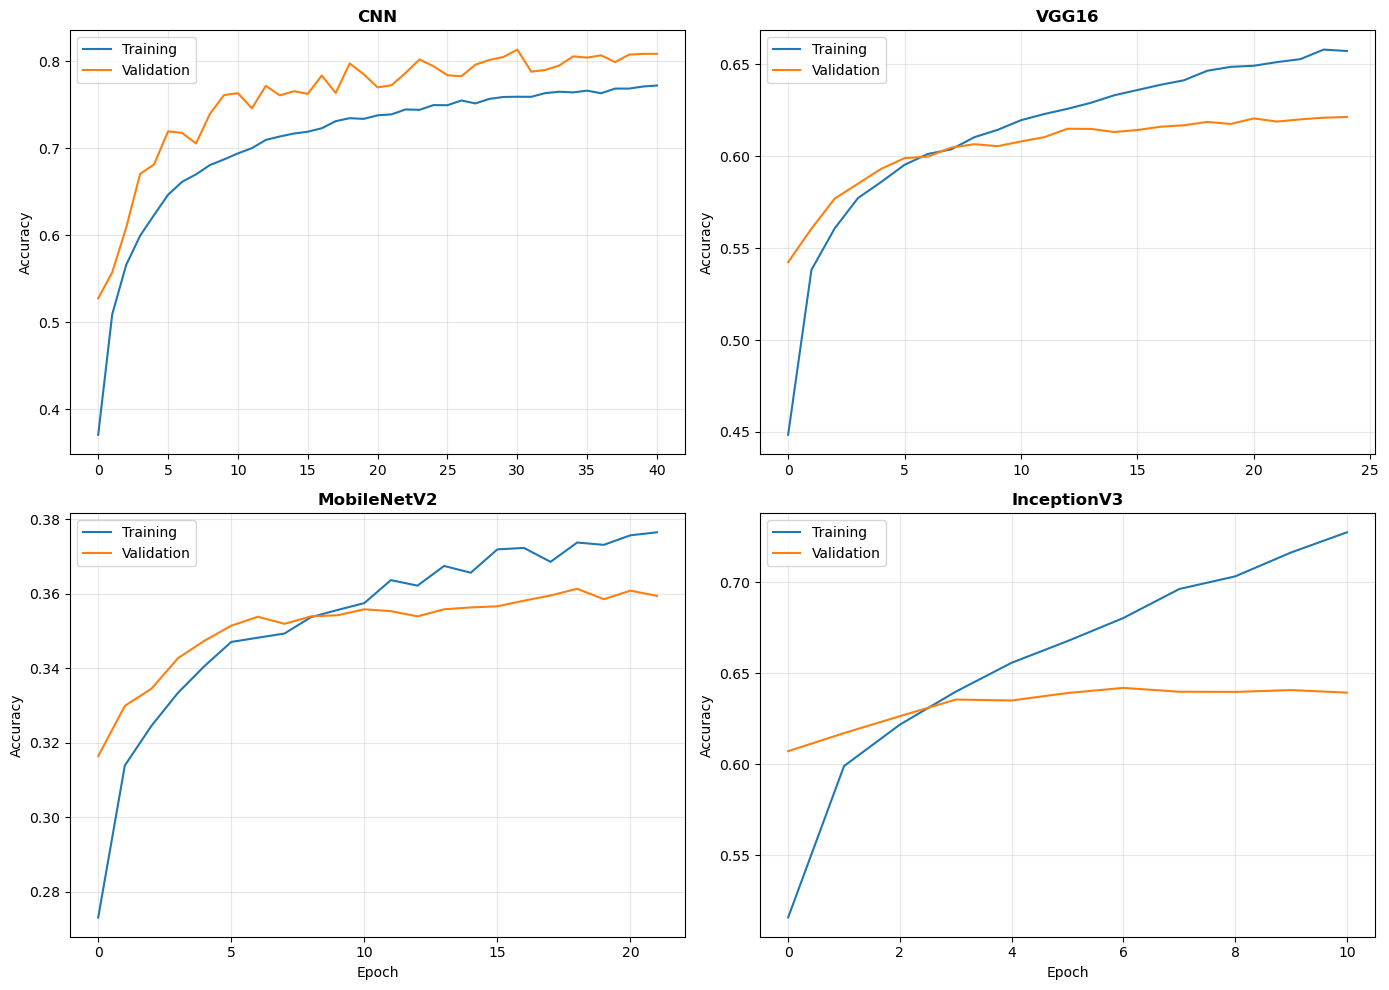

In [ ]:
# --- DIAGNOSTICS: Comparative Analysis of Learning Curves ---

# 1. Create a 2x2 grid of subplots for a side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- PLOT 1: Custom CNN (The Baseline) ---
axes[0, 0].plot(history_cnn.history['accuracy'], label='Training')
axes[0, 0].plot(history_cnn.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('Custom CNN Baseline', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# --- PLOT 2: VGG16 (Transfer Learning - Deep) ---
axes[0, 1].plot(history_vgg.history['accuracy'], label='Training')
axes[0, 1].plot(history_vgg.history['val_accuracy'], label='Validation')
axes[0, 1].set_title('VGG16 Transfer Learning', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# --- PLOT 3: MobileNetV2 (Transfer Learning - Efficient) ---
axes[1, 0].plot(history_mobilenet.history['accuracy'], label='Training')
axes[1, 0].plot(history_mobilenet.history['val_accuracy'], label='Validation')
axes[1, 0].set_title('MobileNetV2 Transfer Learning', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- PLOT 4: InceptionV3 (Transfer Learning - Advanced) ---
axes[1, 1].plot(history_inception.history['accuracy'], label='Training')
axes[1, 1].plot(history_inception.history['val_accuracy'], label='Validation')
axes[1, 1].set_title('InceptionV3 Transfer Learning', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 2. Final layout adjustment and file export
plt.tight_layout() # Prevents label overlapping
plt.savefig('training_curves_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:

# BEST MODEL JUSTIFICATION
print("=== BEST MODEL JUSTIFICATION ===")


justifications = {
    'CNN Custom': """
    - Lightweight and fast to train
    - Low memory usage
    - Good for learning deep learning basics
    - Does not leverage pre-trained features
    """,
    
    'VGG16': """
    - Simple and clear architecture
    - Good classification accuracy
    - More complex than CNN Custom
    - Requires more training time
    """,
    
    'MobileNetV2': """
    - Optimized for mobile devices
    - Very efficient in resource usage
    - Good accuracy-to-speed ratio
    - Ideal for deployment on resource-limited devices
    """,
    
    'InceptionV3': """
    - Complex and powerful architecture
    - Excellent at capturing complex features
    - High accuracy but requires more resources
    - Best for large and complex datasets
    """
}

print(f"✅ SELECTED BEST MODEL: {best_model_name}\n")
print(justifications[best_model_name])


=== BEST MODEL JUSTIFICATION ===

✅ SELECTED BEST MODEL: CNN Custom


    - Lightweight and fast to train
    - Low memory usage
    - Good for learning deep learning basics
    - Does not leverage pre-trained features
    


In [50]:
# =====================================================
# SAVE ALL MODELS
# =====================================================

print("\nSaving all models...\n")
model_cnn.save('model_cnn_custom_cifar10.h5')
print("CNN saved")

model_vgg.save('model_vgg16_cifar10.h5')
print("VGG16 saved")

model_mobilenet.save('model_mobilenetv2_cifar10.h5')
print("MobileNetV2 saved")

model_inception.save('model_inceptionv3_cifar10.h5')
print("InceptionV3 saved")

# Save best model with special name
if best_model_name == 'CNN':
    best_model = model_cnn
elif best_model_name == 'VGG16':
    best_model = model_vgg
elif best_model_name == 'MobileNetV2':
    best_model = model_mobilenet
else:
    best_model = model_inception

best_model.save('best_model_cifar10.h5')
print(f"\nBest model ({best_model_name}) saved as 'best_model_cifar10.h5'")



Saving all models...

CNN saved


VGG16 saved
MobileNetV2 saved


InceptionV3 saved

Best model (CNN Custom) saved as 'best_model_cifar10.h5'


In [51]:

# =====================================================
# MAKE PREDICTIONS WITH BEST MODEL
# =====================================================

print("\n" + "="*50)
print("=== PREDICTIONS WITH BEST MODEL ===")
print("="*50 + "\n")

def predict_image_cnn(image, normalized=True):
    """
    Makes prediction on a single image with CNN Custom model.
    Args:
        image: numpy array of image
        normalized: whether data is normalized or not
    """
    if not normalized:
        image = image.astype('float32') / 255.0
    
    image_expanded = np.expand_dims(image, axis=0)
    prediction = model_cnn.predict(image_expanded, verbose=0)
    
    return prediction[0]

def predict_image_transfer(image, model, normalized=True):
    """
    Makes prediction on a single image with transfer learning model.
    """
    if not normalized:
        image = image.astype('float32') / 255.0
    
    image_resized = tf.image.resize(np.expand_dims(image, axis=0), (224, 224))
    prediction = model.predict(image_resized, verbose=0)
    
    return prediction[0]

# Display predictions
print(f"Predictions with {best_model_name}:\n")
for i in range(5):
    idx = np.random.randint(0, len(x_test))
    
    if best_model_name == 'CNN Custom':
        probs = predict_image_cnn(x_test_normalized[idx], normalized=True)
    else:
        probs = predict_image_transfer(x_test_normalized[idx], best_model, normalized=True)
    
    predicted_class = classes[np.argmax(probs)]
    confidence = np.max(probs) * 100
    true_class = classes[y_test_classes[idx]]
    is_correct = "✅" if predicted_class == true_class else "❌"
    
    print(f"\nSample {i+1}: {is_correct}")
    print(f"  True class:      {true_class}")
    print(f"  Prediction:      {predicted_class}")
    print(f"  Confidence:      {confidence:.2f}%")


=== PREDICTIONS WITH BEST MODEL ===

Predictions with CNN Custom:


Sample 1: ✅
  True class:      bird
  Prediction:      bird
  Confidence:      38.53%

Sample 2: ❌
  True class:      airplane
  Prediction:      ship
  Confidence:      58.71%

Sample 3: ✅
  True class:      bird
  Prediction:      bird
  Confidence:      79.65%

Sample 4: ✅
  True class:      truck
  Prediction:      truck
  Confidence:      96.56%

Sample 5: ✅
  True class:      truck
  Prediction:      truck
  Confidence:      100.00%


In [22]:
import tensorflow as tf
import os
import shutil

# 1. Definimos la ruta de la versión 1
model_version = "1"
export_path = os.path.join("deployed_model", model_version)

# 2. LIMPIEZA: Borramos si ya existe para evitar errores de "Directory not empty"
if os.path.exists(export_path):
    shutil.rmtree(export_path)

# 3. EXPORTACIÓN: Usamos el nuevo método .export() de Keras 3
try:
    # .export() es el sustituto oficial de save_format='tf' para servir modelos
    model_cnn.export(export_path)
    
    print(f"✅ ¡POR FIN! Modelo exportado con éxito en: {export_path}")
    print("Verifica tu carpeta: ahora deberías ver 'saved_model.pb' dentro de '1'.")
    
except AttributeError:
    # Si por alguna razón tu versión de Keras es 3 pero no reconoce .export(), 
    # usamos esta alternativa que es un puente de TensorFlow:
    tf.keras.models.save_model(model_cnn, export_path)
    print(f"✅ Modelo exportado usando save_model en: {export_path}")
except Exception as e:
    print(f"❌ Error inesperado: {e}")

INFO:tensorflow:Assets written to: deployed_model/1/assets


INFO:tensorflow:Assets written to: deployed_model/1/assets


Saved artifact at 'deployed_model/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_78')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  6332504336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6375369296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6438427472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6438738384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6438733968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6438738768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6438738576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6438742608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6438742416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6438742992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6438742800: TensorSpec(shape=(), dtype=tf.resource, name=None)